# Сегментация изображений с помощью архитектуры U-Net
**Задача:** Сегментация искусственно сгенерированных кругов на зашумленном фоне\
**Архитектура:** Классический U-Net без предобученных весов\
**Метрика качества:** Intersection over Union\
**Функция потерь:** Binary Cross-Entropy (BCEWithLogitsLoss).

## 1. Подготовка данных и Генерация датасета
Мы генерируем датасет "на лету" с помощью написанного ранее ноутбука `circles_generator.ipynb`. Каждое изображение содержит случайные круги на зашумленном фоне. Данные сразу упаковываются в класс `Dataset` для PyTorch.

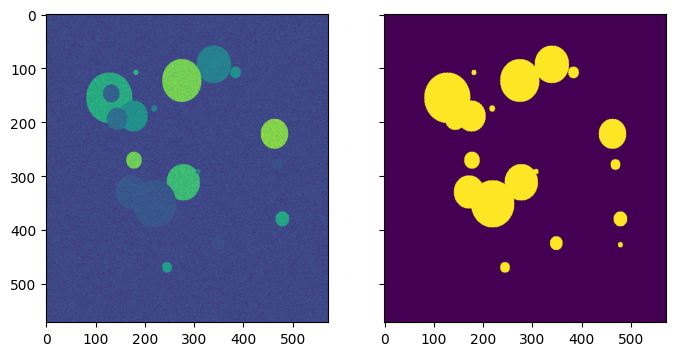

Генерация 1 изображений...


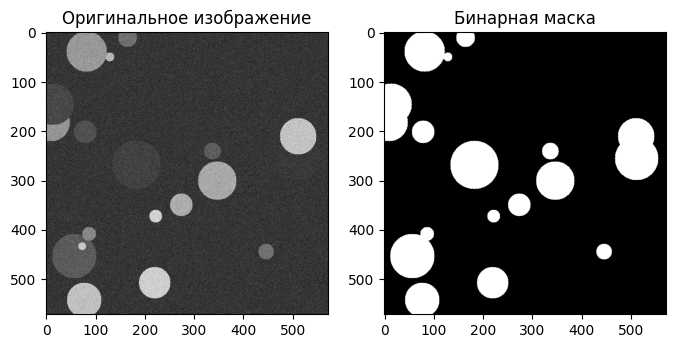

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

# Выполняем скрипт с логикой генерации кругов напрямую в Jupyter
%run circles_generator.ipynb

class CirclesDataset(Dataset):
    def __init__(self, num_samples, nx=128, ny=128, **kwargs):
        '''Создаем датасет, генерируя картинки заранее в память для скорости.'''
        self.num_samples = num_samples
        print(f"Генерация {num_samples} изображений...")
        self.images = []
        self.masks = []
        
        # Используем функцию из circles_generator
        for _ in range(num_samples):
            # img: (nx, ny, 1), mask: (nx, ny) для бинарной маски
            img, mask = create_image_and_label(nx, ny, **kwargs)
            
            # PyTorch ожидает каналы в начале: (C, H, W)
            img = img.transpose((2, 0, 1)).astype(np.float32)
            mask = np.expand_dims(mask, axis=0).astype(np.float32)
            
            self.images.append(img)
            self.masks.append(mask)
            
    def __len__(self):
        return self.num_samples
    
    def __getitem__(self, idx):
        return torch.tensor(self.images[idx]), torch.tensor(self.masks[idx])

# Размер картинок и количество кругов
IMG_SIZE = 572 
NUM_CIRCLES = 20

# Тестовая визуализация
temp_dataset = CirclesDataset(num_samples=1, nx=IMG_SIZE, ny=IMG_SIZE, cnt=NUM_CIRCLES, border=10)
img, mask = temp_dataset[0]

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(img[0].numpy(), cmap='gray')
ax[0].set_title("Оригинальное изображение")
ax[1].imshow(mask[0].numpy(), cmap='gray')
ax[1].set_title("Бинарная маска")
plt.show()

## 2. Архитектура нейронной сети (U-Net)
Мы реализуем классическую архитектуру U-Net, состоящую из:
*   **Энкодера (Down):** Последовательное уменьшение размерности изображения с увеличением числа каналов (извлечение признаков).
*   **Декодера (Up):** Постепенное восстановление исходного размера изображения с помощью **ConvTranspose2d**.
*   **Skip-connections (Мостиков):** Перенос детальной информации из энкодера в декодер для точного позиционирования маски.

In [2]:
class DoubleConv(nn.Module):
    '''(Свертка => BatchNorm => ReLU) * 2 раза'''
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.double_conv(x)

class Down(nn.Module):
    '''Сжатие: MaxPool -> DoubleConv'''
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )
    def forward(self, x):
        return self.maxpool_conv(x)

class Up(nn.Module):
    '''Восстановление: Обратная свертка -> Конкатенация (Мостик) -> DoubleConv'''
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)
        
    def forward(self, x1, x2):
        x1 = self.up(x1)
        
        # Выравниваем размеры, если при пуллинге обрезались нечетные края
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])
        
        # SKIP CONNECTION (Мостик): склеиваем признаки декодера (x1) и энкодера (x2)
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, n_channels=1, n_classes=1):
        super(UNet, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        
        # Энкодер (спускаемся вниз буквы U)
        self.inc = DoubleConv(n_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        
        # Декодер (поднимаемся вверх буквы U)
        self.up1 = Up(512, 256)
        self.up2 = Up(256, 128)
        self.up3 = Up(128, 64)
        
        # Финальный слой предсказания (1 канал = 1 маска)
        self.outc = nn.Conv2d(64, n_classes, kernel_size=1)
        
    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        
        x = self.up1(x4, x3)
        x = self.up2(x, x2)
        x = self.up3(x, x1)
        logits = self.outc(x)
        return logits

## 3. Подготовка выборок и Метрика качества (IoU)
Мы генерируем 1000 изображений и разбиваем их на обучающую (80%), тестовую (10%) и валидационную (10%) выборки. Для оценки качества мы реализуем функцию Intersection over Union (IoU), которая вычисляет площадь пересечения истинной и предсказанной маски, деленную на их объединение.

In [15]:
from sklearn.model_selection import train_test_split

total_samples = 3000
full_dataset = CirclesDataset(num_samples=total_samples, nx=IMG_SIZE, ny=IMG_SIZE, cnt=NUM_CIRCLES, border=10)

all_images = [full_dataset[i][0] for i in range(total_samples)]
all_masks = [full_dataset[i][1] for i in range(total_samples)]

# Разбиваем на Train (80%) и Temp (20%)
X_train, X_temp, y_train, y_temp = train_test_split(all_images, all_masks, test_size=0.2, random_state=42)
# Temp разбиваем пополам на Test (10%) и Validation (10%)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

class SimpleDataset(Dataset):
    '''Простая обертка датасета для DataLoader'''
    def __init__(self, images, masks):
        self.images = images
        self.masks = masks
    def __len__(self):
        return len(self.images)
    def __getitem__(self, idx):
        return self.images[idx], self.masks[idx]

train_loader = DataLoader(SimpleDataset(X_train, y_train), batch_size=16, shuffle=True)
test_loader = DataLoader(SimpleDataset(X_test, y_test), batch_size=16, shuffle=False)
val_loader = DataLoader(SimpleDataset(X_val, y_val), batch_size=16, shuffle=False)

print(f"Размер выборок | Train: {len(X_train)} | Test: {len(X_test)} | Val: {len(X_val)}")

def calculate_iou(preds, labels, threshold=0.5):
    '''Вычисляет метрику IoU для батча. Чем ближе к 1.0, тем точнее маска совпадает с истиной.'''
    # Сеть выдает "сырые" логиты, переводим их в вероятности (через Сигмоиду) 
    preds = torch.sigmoid(preds)
    preds = (preds > threshold).float()
    
    intersection = (preds * labels).sum(dim=(2, 3))
    union = preds.sum(dim=(2, 3)) + labels.sum(dim=(2, 3)) - intersection
    
    # Чтобы избежать деления на ноль, добавляем небольшое число (epsilon)
    iou = (intersection + 1e-6) / (union + 1e-6)
    return iou.mean().item()

Генерация 3000 изображений...
Размер выборок | Train: 2400 | Test: 300 | Val: 300


In [16]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super(DiceLoss, self).__init__()
        self.smooth = smooth
    def forward(self, inputs, targets):
        # Применяем сигмоиду, так как на выходе модели логиты
        inputs = torch.sigmoid(inputs)
        
        # Вытягиваем тензоры в один вектор
        inputs = inputs.view(-1)
        targets = targets.view(-1)
        
        # Считаем пересечение
        intersection = (inputs * targets).sum()                            
        dice = (2. * intersection + self.smooth) / (inputs.sum() + targets.sum() + self.smooth)  
        
        return 1 - dice

## 4. Инициализация и Обучение модели
Используем гибридную функцию потерь **BCEWithLogitsLoss + DiceLoss** — для бинарной классификации пикселей и регуляризатора формы, и стандартный оптимизатор Adam. В процессе обучения следим за метриками на тестовой выборке.

In [17]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используем устройство: {device}")

model = UNet(n_channels=1, n_classes=1).to(device)
criterion_bce = nn.BCEWithLogitsLoss()
criterion_dice = DiceLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 10

train_losses, test_losses = [], []
train_ious, test_ious = [], []

print("Начинаем обучение...")
for epoch in range(num_epochs):
    # --- ОБУЧЕНИЕ ---
    model.train()
    running_loss, running_iou = 0.0, 0.0
    
    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        running_iou += calculate_iou(outputs, masks)
        
    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_iou = running_iou / len(train_loader)
    train_losses.append(epoch_train_loss)
    train_ious.append(epoch_train_iou)
    
    # --- ТЕСТИРОВАНИЕ (В ПРОЦЕССЕ ОБУЧЕНИЯ) ---
    model.eval()
    running_loss, running_iou = 0.0, 0.0
    with torch.no_grad():
        for images, masks in test_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = criterion_bce(outputs, masks) + criterion_dice(outputs, masks)
            
            running_loss += loss.item()
            running_iou += calculate_iou(outputs, masks)
            
    epoch_test_loss = running_loss / len(test_loader)
    epoch_test_iou = running_iou / len(test_loader)
    test_losses.append(epoch_test_loss)
    test_ious.append(epoch_test_iou)
    
    print(f"Эпоха {epoch+1}/{num_epochs} "
          f"| Train Loss: {epoch_train_loss:.4f} IoU: {epoch_train_iou:.4f} "
          f"| Test Loss: {epoch_test_loss:.4f} IoU: {epoch_test_iou:.4f}")

Используем устройство: cuda
Начинаем обучение...
Эпоха 1/10 | Train Loss: 0.1440 IoU: 0.8914 | Test Loss: 0.2312 IoU: 0.9032
Эпоха 2/10 | Train Loss: 0.0674 IoU: 0.9016 | Test Loss: 0.1526 IoU: 0.8992
Эпоха 3/10 | Train Loss: 0.0595 IoU: 0.9064 | Test Loss: 0.1458 IoU: 0.9098
Эпоха 4/10 | Train Loss: 0.0578 IoU: 0.9087 | Test Loss: 0.1267 IoU: 0.9277
Эпоха 5/10 | Train Loss: 0.0481 IoU: 0.9253 | Test Loss: 0.0951 IoU: 0.9341
Эпоха 6/10 | Train Loss: 0.0441 IoU: 0.9322 | Test Loss: 0.0884 IoU: 0.9425
Эпоха 7/10 | Train Loss: 0.0345 IoU: 0.9490 | Test Loss: 0.0716 IoU: 0.9568
Эпоха 8/10 | Train Loss: 0.0331 IoU: 0.9523 | Test Loss: 0.1013 IoU: 0.9476
Эпоха 9/10 | Train Loss: 0.0336 IoU: 0.9502 | Test Loss: 0.0681 IoU: 0.9533
Эпоха 10/10 | Train Loss: 0.0286 IoU: 0.9586 | Test Loss: 0.0740 IoU: 0.9631


## 5. Оценка результатов и Визуализация
Построим графики процесса обучения, чтобы убедиться в отсутствии переобучения. Затем прогоним сеть на отложенной валидационной выборке и выведем результат.

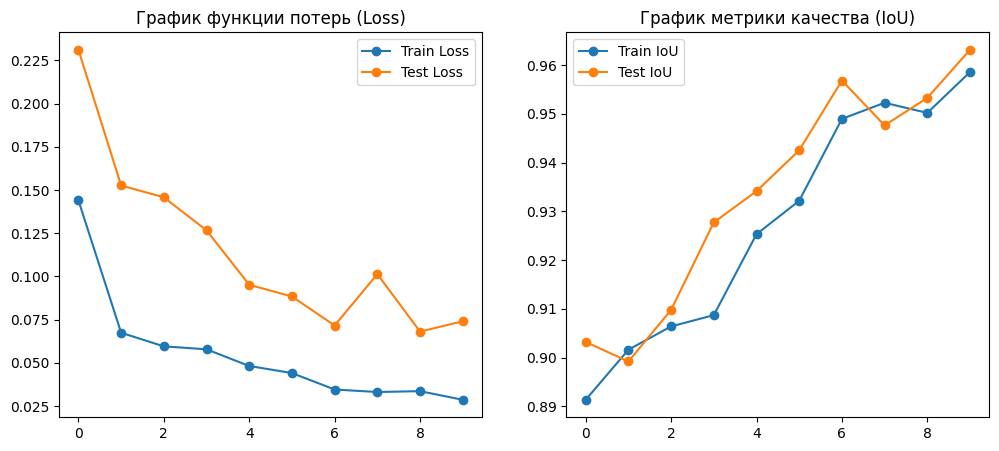

=== ИТОГОВАЯ ВАЛИДАЦИОННАЯ ВЫБОРКА ===
Loss: 0.0249 | IoU: 0.9655



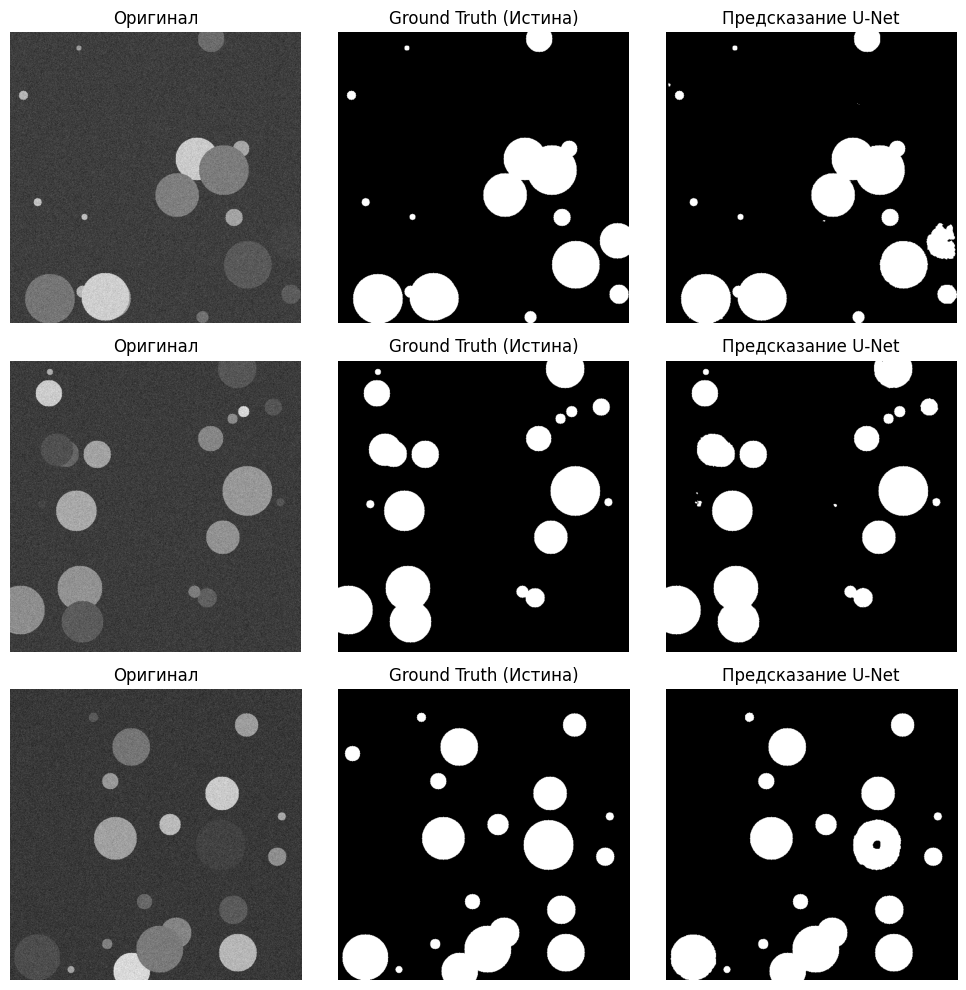

In [24]:
# 1. Строим графики Loss и IoU
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(train_losses, label='Train Loss', marker='o')
ax[0].plot(test_losses, label='Test Loss', marker='o')
ax[0].set_title('График функции потерь (Loss)')
ax[0].legend()

ax[1].plot(train_ious, label='Train IoU', marker='o')
ax[1].plot(test_ious, label='Test IoU', marker='o')
ax[1].set_title('График метрики качества (IoU)')
ax[1].legend()
plt.show()

# 2. Итоговая оценка на валидационной выборке
model.eval()
val_loss, val_iou = 0.0, 0.0
with torch.no_grad():
    for images, masks in val_loader:
        images, masks = images.to(device), masks.to(device)
        outputs = model(images)
        val_loss += criterion(outputs, masks).item()
        val_iou += calculate_iou(outputs, masks)
        
print(f"=== ИТОГОВАЯ ВАЛИДАЦИОННАЯ ВЫБОРКА ===\nLoss: {val_loss/len(val_loader):.4f} | IoU: {val_iou/len(val_loader):.4f}\n")

# 3. Наглядная визуализация: Оригинал -> Истинная маска -> Предсказание
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for i in range(3):
    img_tensor, mask_tensor = val_loader.dataset[i]
    img_device = img_tensor.unsqueeze(0).to(device)
    
    with torch.no_grad():
        pred_mask = model(img_device)
        # Получаем итоговую маску через Сигмоиду
        pred_mask = torch.sigmoid(pred_mask) > 0.5 
        
    axes[i, 0].imshow(img_tensor[0].numpy(), cmap='gray')
    axes[i, 0].set_title("Оригинал")
    
    axes[i, 1].imshow(mask_tensor[0].numpy(), cmap='gray')
    axes[i, 1].set_title("Ground Truth (Истина)")
    
    axes[i, 2].imshow(pred_mask[0, 0].cpu().numpy(), cmap='gray')
    axes[i, 2].set_title("Предсказание U-Net")
    
    for ax in axes[i]:
        ax.axis('off')
        
plt.tight_layout()
plt.show()

### Сохранение и загрузка весов модели

In [22]:
torch.save(model.state_dict(), 'unet_circles_weights.pth')
print("Веса модели успешно сохранены")

Веса модели успешно сохранены


In [23]:
model = UNet().to(device)

model.load_state_dict(torch.load('unet_circles_weights.pth', weights_only=True))
# 3. ВАЖНО: переводим модель в режим оценки (тестирования)
# Это нужно, чтобы слои вроде BatchNorm работали правильно при инференсе
model.eval()
print("Модель загружена")

Модель загружена
